# 02. Embeddings e Redução de Dimensionalidade

## Objetivo

Este notebook transforma as descrições de texto em representações vetoriais e avalia diferentes formas de fazer isso, antes de decidir qual delas vamos usar na modelagem. Testamos duas rotas: gerar embeddings (vetores densos, a partir de um modelo neural) e depois comprimi-los com PCA ou UMAP, e também o TF-IDF, uma representação clássica baseada só nas palavras do texto, sem nenhum embedding por trás.

```
texto  -->  embedding numérico  -->  PCA ou UMAP  -->  representação reduzida
texto  -->  TF-IDF  -->  representação esparsa (sem redução)
```

In [1]:
import sys
sys.path.append('../src')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import umap

from preprocessing import carregar_e_limpar, sanitizar_reducao

import warnings
warnings.filterwarnings('ignore')

/usr/local/lib/python3.11/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Carregar os dados preparados no notebook anterior

In [2]:
df = carregar_e_limpar('../data/raw/dataset_ecommerce.csv')

le = LabelEncoder()
y = le.fit_transform(df['categoria'])

idx = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    idx, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Dataset: {df.shape} | Treino: {len(idx_train)} | Teste: {len(idx_test)}")

Dataset: (27802, 2) | Treino: 22241 | Teste: 5561


## 2. Gerar embeddings

In [3]:
caminho_embeddings = '../data/raw/embeddings_texto.npy'

if os.path.exists(caminho_embeddings):
    print("[INFO] Carregando embeddings do disco...")
    embeddings_completos = np.load(caminho_embeddings)
    # embeddings_texto.npy foi gerado uma única vez, para as linhas sem nulos
    # (antes da deduplicação). df.index preserva essa posição original, então
    # usamos para selecionar só as linhas que sobreviveram à limpeza completa.
    embeddings = embeddings_completos[df.index.values]
else:
    print("[INFO] Gerando novos embeddings...")
    from sentence_transformers import SentenceTransformer
    model_embed = SentenceTransformer('sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2')
    embeddings = model_embed.encode(df['texto'].tolist(), show_progress_bar=True)
    np.save(caminho_embeddings, embeddings)

assert embeddings.shape[0] == len(df), "Embeddings e dataset limpo têm tamanhos diferentes!"
print(f"Embeddings: {embeddings.shape}")

[INFO] Carregando embeddings do disco...


Embeddings: (27802, 384)


## 3. Verificar embeddings

In [4]:
print(f"Cada descrição foi representada por um vetor de {embeddings.shape[1]} dimensões.")
print(f"\nExemplo — texto: {df['texto'].iloc[0][:100]}...")
print(f"Primeiras 10 posições do embedding: {np.round(embeddings[0][:10], 3)}")

emb_train, emb_test = embeddings[idx_train], embeddings[idx_test]

Cada descrição foi representada por um vetor de 384 dimensões.

Exemplo — texto: Paper Plane Design Framed Wall Hanging Motivational Office Decor Art Prints (8.7 X 8.7 inch) - Set o...
Primeiras 10 posições do embedding: [-0.014  0.255 -0.32  -0.029 -0.091  0.163 -0.111  0.04   0.044  0.167]


## 4. PCA com 10, 20 e 30 dimensões

O PCA é ajustado só com os dados de treino (`emb_train`) e depois aplicado ao teste através do `transform`. Fazemos assim para não vazar nenhuma informação do teste durante a redução de dimensionalidade.

In [5]:
os.makedirs('../data/processed/embeddings_reducoes', exist_ok=True)
dims = [10, 20, 30]

for dim in dims:
    pca = PCA(n_components=dim, random_state=42)
    X_tr = pca.fit_transform(emb_train)
    X_te = pca.transform(emb_test)
    X_tr, X_te = sanitizar_reducao(X_tr, X_te, contexto=f"PCA {dim}D")
    np.savez(f'../data/processed/embeddings_reducoes/pca_{dim}.npz', X_train=X_tr, X_test=X_te)
    print(f"PCA {dim:>2}D — variância explicada acumulada: {pca.explained_variance_ratio_.sum():.3f}")

PCA 10D — variância explicada acumulada: 0.298
PCA 20D — variância explicada acumulada: 0.428
PCA 30D — variância explicada acumulada: 0.523


## 5. UMAP com 10, 20 e 30 dimensões

A lógica é a mesma do PCA: o ajuste acontece só no treino e o teste passa pelo transform. Uma diferença é que aqui não fixamos o `random_state`. Isso permite que o UMAP use os dois núcleos disponíveis através do `n_jobs=2` e deixa o ajuste cerca de 35% mais rápido nesta base. Como o UMAP não é supervisionado, pequenas variações entre uma execução e outra não atrapalham a comparação relativa entre representações e modelos que fazemos no notebook 03.

Por não fixar o `random_state`, o `transform` do UMAP em dados de teste pode ocasionalmente gerar algum NaN em pontos fora da região bem representada do espaço aprendido no treino. Por isso, logo depois de cada redução chamamos `sanitizar_reducao`, que imputa qualquer NaN pela média do treino e avisa quando isso acontece.

In [6]:
for dim in dims:
    reducer = umap.UMAP(n_components=dim, n_jobs=2)
    X_tr = reducer.fit_transform(emb_train)
    X_te = reducer.transform(emb_test)
    X_tr, X_te = sanitizar_reducao(X_tr, X_te, contexto=f"UMAP {dim}D")
    np.savez(f'../data/processed/embeddings_reducoes/umap_{dim}.npz', X_train=X_tr, X_test=X_te)
    print(f"UMAP {dim:>2}D — concluído ({X_tr.shape[0]} treino / {X_te.shape[0]} teste)")

UMAP 10D — concluído (22241 treino / 5561 teste)


UMAP 20D — concluído (22241 treino / 5561 teste)


UMAP 30D — concluído (22241 treino / 5561 teste)


## 6. TF-IDF (representação alternativa, sem embedding)

O PCA e o UMAP partem do embedding gerado por um modelo neural. O TF-IDF é diferente: ele representa cada texto diretamente pelas palavras que aparecem nele, sem nenhum modelo treinado por trás. Cada posição do vetor corresponde a uma palavra do vocabulário, e o valor combina duas coisas, a frequência da palavra no texto e o quão rara ela é no restante da base. É uma representação bem mais simples, esparsa (a maioria das posições é zero) e de dimensão bem maior que os embeddings.

Limitamos o vocabulário às 5000 palavras mais informativas (`max_features=5000`) e ignoramos palavras que aparecem em menos de 2 documentos (`min_df=2`), só para não deixar o vocabulário explodir com erros de digitação e termos únicos. O `TfidfVectorizer` é ajustado (`fit`) só no treino, igual fizemos com o PCA e o UMAP, para não vazar nenhuma estatística do vocabulário de teste. Diferente do PCA e do UMAP, não reduzimos a dimensão do TF-IDF aqui: ele entra na comparação do notebook 03 do jeito que é usado na prática, em alta dimensão.

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
import scipy.sparse as sp

texto_train = df['texto'].values[idx_train]
texto_test = df['texto'].values[idx_test]

tfidf = TfidfVectorizer(max_features=5000, min_df=2)
X_tr_tfidf = tfidf.fit_transform(texto_train)
X_te_tfidf = tfidf.transform(texto_test)

sp.save_npz('../data/processed/embeddings_reducoes/tfidf_train.npz', X_tr_tfidf)
sp.save_npz('../data/processed/embeddings_reducoes/tfidf_test.npz', X_te_tfidf)

densidade = X_tr_tfidf.nnz / (X_tr_tfidf.shape[0] * X_tr_tfidf.shape[1]) * 100
print(f"TF-IDF treino: {X_tr_tfidf.shape} | TF-IDF teste: {X_te_tfidf.shape}")
print(f"Tamanho do vocabulário: {len(tfidf.vocabulary_)} palavras")
print(f"Densidade (proporção de valores não-zero): {densidade:.2f}%")

TF-IDF treino: (22241, 5000) | TF-IDF teste: (5561, 5000)
Tamanho do vocabulário: 5000 palavras
Densidade (proporção de valores não-zero): 1.15%


## 7. Visualização em 2D

As reduções feitas acima serão usadas para treinar e avaliar modelos, mas esta projeção em 2D tem outro propósito: é só exploratória. Como não estamos avaliando nenhum modelo aqui, ajustamos o UMAP na base inteira, juntando treino e teste, apenas para enxergar visualmente se as categorias formam regiões separadas no espaço.

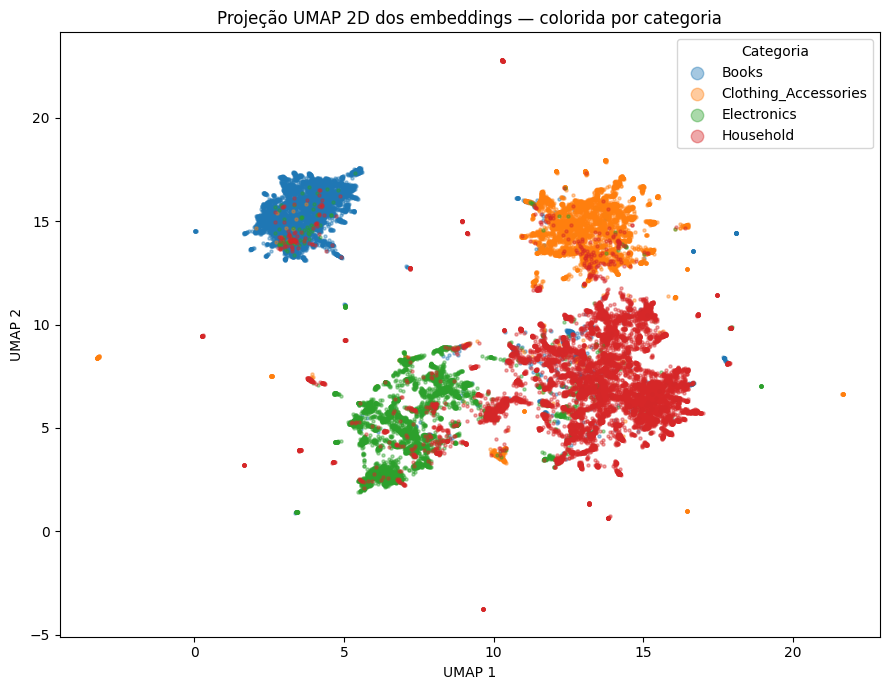

In [8]:
reducer_2d = umap.UMAP(n_components=2, n_jobs=2)
emb_2d = reducer_2d.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
categorias_plot = df['categoria'].values
for cat in sorted(df['categoria'].unique()):
    mask = categorias_plot == cat
    plt.scatter(emb_2d[mask, 0], emb_2d[mask, 1], s=5, alpha=0.4, label=cat)
plt.legend(markerscale=4, title='Categoria')
plt.title('Projeção UMAP 2D dos embeddings — colorida por categoria')
plt.xlabel('UMAP 1')
plt.ylabel('UMAP 2')
plt.tight_layout()
plt.show()

## Fechamento

A pergunta que este notebook tentou responder foi: como representar os textos?

Testamos o PCA, que é linear, e o UMAP, que é não linear, em 10, 20 e 30 dimensões, sempre ajustando o reducer apenas no treino, e também o TF-IDF, que representa o texto diretamente pelas palavras que ele contém, sem passar por nenhum embedding. As representações ficaram salvas em `../data/processed/embeddings_reducoes/`, para serem reaproveitadas no próximo notebook sem precisar recalcular o UMAP, que é a etapa mais custosa computacionalmente deste projeto.

Ainda não escolhemos qual representação vamos usar. Essa decisão é feita no notebook `03_modelagem_avaliacao.ipynb`, com base no desempenho real de cada configuração combinada com os modelos.